# EDA — WB HACK 2026 (Solo Track)
Полный разведочный анализ train и test данных с инсайтами для моделирования.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.figsize'] = (14, 5)

STATUS_COLS = [f'status_{i}' for i in range(1, 7)]
TARGET = 'target_1h'

## 1. Загрузка данных

In [3]:
train = pd.read_parquet('train_solo_track.parquet')
test  = pd.read_parquet('test_solo_track.parquet')

train['timestamp'] = pd.to_datetime(train['timestamp'])
test['timestamp']  = pd.to_datetime(test['timestamp'])

train = train.sort_values(['route_id', 'timestamp']).reset_index(drop=True)
test  = test.sort_values(['route_id', 'timestamp']).reset_index(drop=True)

print('Train shape:', train.shape)
print('Test  shape:', test.shape)
print()
print('Train date range:', train.timestamp.min(), '->', train.timestamp.max())
print('Test  date range:', test.timestamp.min(),  '->', test.timestamp.max())
print()
train.head(3)

Train shape: (4630000, 9)
Test  shape: (8000, 3)

Train date range: 2025-07-28 00:00:00 -> 2025-11-01 10:30:00
Test  date range: 2025-11-01 11:00:00 -> 2025-11-01 14:30:00



,route_id,timestamp,status_1,status_2,status_3,status_4,status_5,status_6,target_1h
0,0,2025-07-28 00:00:00,13,13,7,58053,136443,97,87359
1,0,2025-07-28 00:30:00,6,18,13,58867,134643,95,182291
2,0,2025-07-28 01:00:00,7,8,27,54848,135534,96,271432


## 2. Структура и качество данных

In [4]:
overview = pd.DataFrame({
    'dtype':       train.dtypes.astype(str),
    'missing_cnt': train.isna().sum(),
    'missing_pct': (train.isna().mean()*100).round(4),
    'n_unique':    train.nunique(dropna=False),
    'min':         train.min(numeric_only=True),
    'max':         train.max(numeric_only=True),
})
display(overview)

# Проверяем равномерность временного ряда по каждому маршруту
rows_per_route = train.groupby('route_id').size()
print(f'\nСтрок на маршрут: min={rows_per_route.min()}, max={rows_per_route.max()} — ', end='')
print('✅ ВСЕ маршруты имеют одинаковое количество точек' if rows_per_route.nunique()==1 else '⚠️ Разное количество точек!')
print(f'Временной шаг: 30 мин | Всего точек на маршрут: {rows_per_route.iloc[0]}')
print(f'Нулей в target: {(train[TARGET]==0).sum()} ({(train[TARGET]==0).mean():.2%})')

,dtype,missing_cnt,missing_pct,n_unique,min,max
route_id,int64,0,0.0,1000,0.0,999.0
status_1,int64,0,0.0,272,0.0,802.0
status_2,int64,0,0.0,243,0.0,522.0
status_3,int64,0,0.0,260,0.0,620.0
status_4,int64,0,0.0,315655,1390.0,587938.0
status_5,int64,0,0.0,1463128,18519.0,3503114.0
status_6,int64,0,0.0,82051,0.0,152739.0
target_1h,int64,0,0.0,692648,0.0,10831337.0
timestamp,datetime64[ns],0,0.0,4630,NaN,NaN



Строк на маршрут: min=4630, max=4630 — ✅ ВСЕ маршруты имеют одинаковое количество точек
Временной шаг: 30 мин | Всего точек на маршрут: 4630
Нулей в target: 69841 (1.51%)


## 3. Ключевой инсайт — тест лежит вплотную к train

In [5]:
train_end  = train.timestamp.max()
test_start = test.timestamp.min()
gap = test_start - train_end
print(f'Train заканчивается: {train_end}')
print(f'Test начинается:     {test_start}')
print(f'Разрыв:              {gap}')
print()
print('Test timestamps:', sorted(test.timestamp.dt.strftime("%H:%M").unique()))
print(f'Кол-во шагов прогноза: {test.timestamp.nunique()} (по 30 мин каждый)')
print()
nov1_train = train[train.timestamp.dt.date == test_start.date()]
print(f'Данные по 1 ноября уже есть в train — {nov1_train.timestamp.nunique()} точек (00:00–10:30)')
print('=> Для каждого маршрута доступны утренние status-значения того же дня!')

Train заканчивается: 2025-11-01 10:30:00
Test начинается:     2025-11-01 11:00:00
Разрыв:              0 days 00:30:00

Test timestamps: ['11:00', '11:30', '12:00', '12:30', '13:00', '13:30', '14:00', '14:30']
Кол-во шагов прогноза: 8 (по 30 мин каждый)

Данные по 1 ноября уже есть в train — 22 точек (00:00–10:30)
=> Для каждого маршрута доступны утренние status-значения того же дня!


## 4. Распределение target_1h

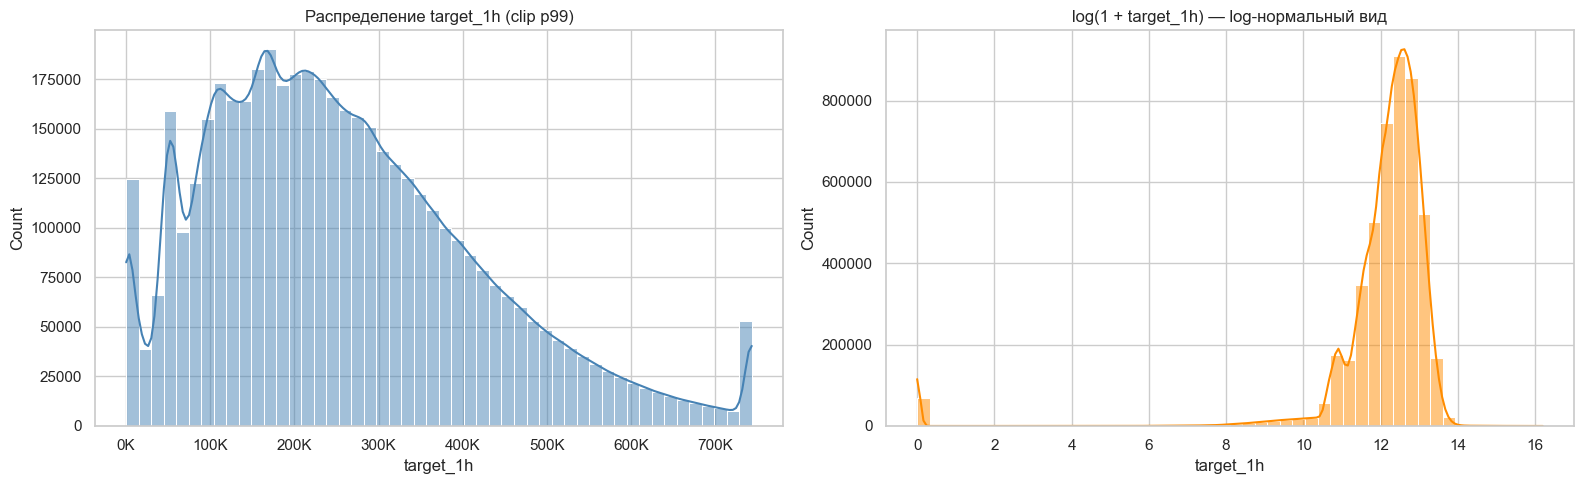

percentile,0,1,5,10,25,50,75,90,95,99,100
value,0,0,44889,70221,138990,235769,355175,480612,564384,743427,10831337



⚠️  Выбросы: 99-й перцентиль = 743K, но max = 10.8M


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

p99 = train[TARGET].quantile(0.99)
sns.histplot(train[TARGET].clip(upper=p99), bins=50, ax=axes[0], kde=True, color='steelblue')
axes[0].set_title('Распределение target_1h (clip p99)')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}K'))

sns.histplot(np.log1p(train[TARGET]), bins=50, ax=axes[1], kde=True, color='darkorange')
axes[1].set_title('log(1 + target_1h) — log-нормальный вид')

plt.tight_layout()
plt.show()

pcts = [0,1,5,10,25,50,75,90,95,99,100]
pct_vals = np.percentile(train[TARGET], pcts)
display(pd.DataFrame({'percentile': pcts, 'value': pct_vals.astype(int)}).set_index('percentile').T)
print(f'\n⚠️  Выбросы: 99-й перцентиль = {p99/1e3:.0f}K, но max = {train[TARGET].max()/1e6:.1f}M')

## 5. Корреляции фичей с таргетом

,Pearson,Spearman
status_2,0.507,0.535
status_1,0.488,0.524
status_3,0.451,0.478
status_4,0.431,0.477
status_5,0.370,0.422
status_6,0.104,0.242


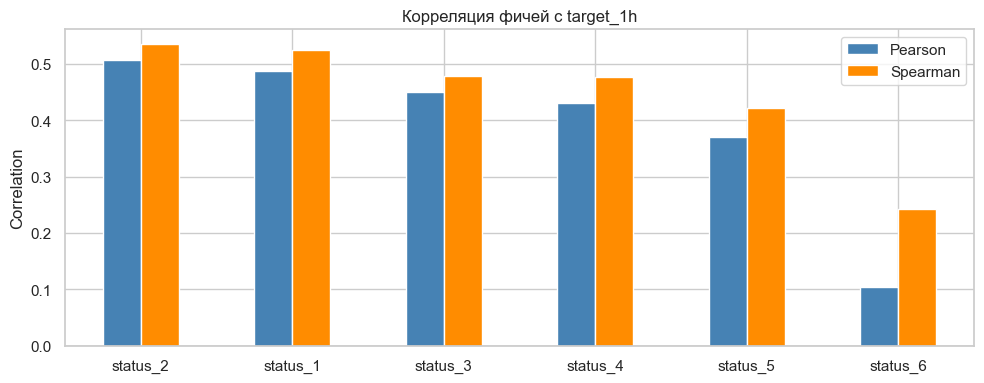

💡 status_1/2/3 — лучшие предикторы (~0.5)
💡 status_6 — слабый предиктор (~0.1), но Spearman тоже низкий => реально слабый


In [7]:
# Pearson корреляция
corr = train[STATUS_COLS + [TARGET]].corr()[TARGET].drop(TARGET).sort_values(ascending=False)

# Spearman (ранговая — устойчива к выбросам)
spearman = train[STATUS_COLS + [TARGET]].corr(method='spearman')[TARGET].drop(TARGET).sort_values(ascending=False)

corr_df = pd.DataFrame({'Pearson': corr, 'Spearman': spearman})
display(corr_df.round(3))

fig, ax = plt.subplots(figsize=(10, 4))
corr_df.plot(kind='bar', ax=ax, color=['steelblue', 'darkorange'])
ax.set_title('Корреляция фичей с target_1h')
ax.set_ylabel('Correlation')
ax.axhline(0, color='black', linewidth=0.8)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print('💡 status_1/2/3 — лучшие предикторы (~0.5)')
print('💡 status_6 — слабый предиктор (~0.1), но Spearman тоже низкий => реально слабый')

## 6. Паттерны по часам

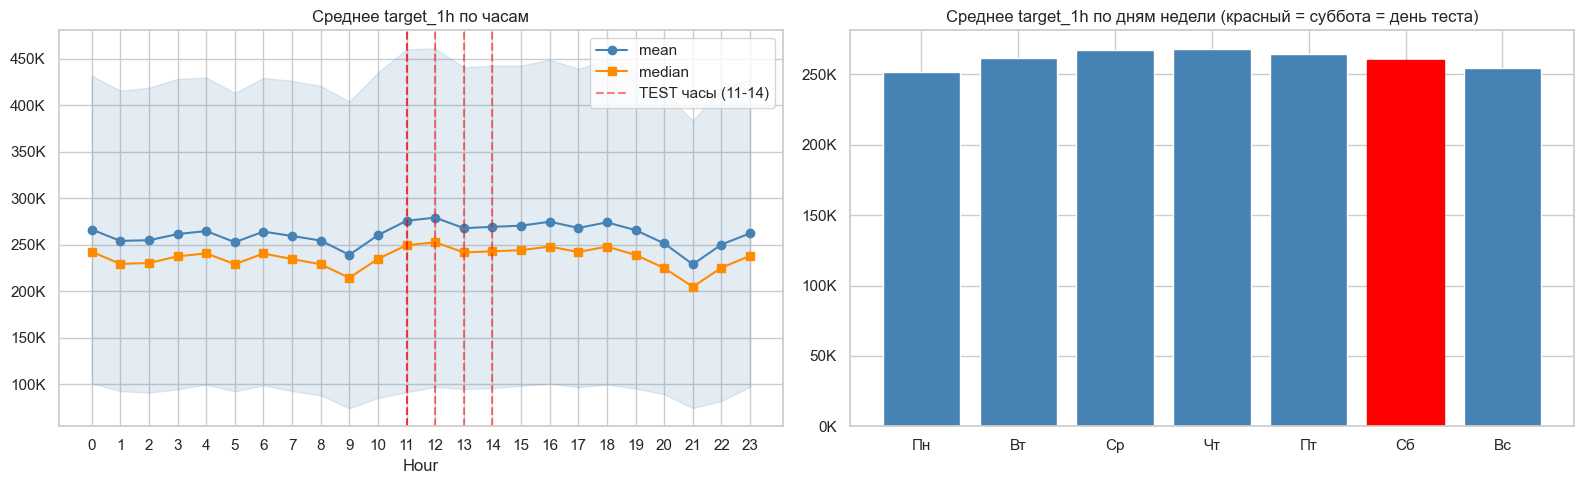

💡 Тестовые часы (11:00–14:30) — выше среднего (пик в 11–12 часов!)
💡 Суббота (1 ноября) — близко к среднему по неделе
   Среднее target в тестовые часы: 273031 vs общее: 261242


In [8]:
train['hour'] = train.timestamp.dt.hour
train['dow']  = train.timestamp.dt.dayofweek

hourly = train.groupby('hour')[TARGET].agg(['mean','median','std']).round(0)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(hourly.index, hourly['mean'],   label='mean',   marker='o', color='steelblue')
axes[0].plot(hourly.index, hourly['median'], label='median', marker='s', color='darkorange')
axes[0].fill_between(hourly.index,
                     hourly['mean'] - hourly['std'],
                     hourly['mean'] + hourly['std'],
                     alpha=0.15, color='steelblue')
# Отмечаем тестовые часы
for h in [11, 12, 13, 14]:
    axes[0].axvline(h, color='red', linestyle='--', alpha=0.5)
axes[0].axvline(11, color='red', linestyle='--', alpha=0.5, label='TEST часы (11-14)')
axes[0].set_title('Среднее target_1h по часам')
axes[0].set_xlabel('Hour')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x/1e3:.0f}K'))
axes[0].legend()
axes[0].set_xticks(range(24))

dow_labels = ['Пн','Вт','Ср','Чт','Пт','Сб','Вс']
dow_mean = train.groupby('dow')[TARGET].mean()
bars = axes[1].bar(dow_labels, dow_mean, color='steelblue')
bars[5].set_color('red')  # Суббота — день теста
axes[1].set_title('Среднее target_1h по дням недели (красный = суббота = день теста)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x/1e3:.0f}K'))

plt.tight_layout()
plt.show()

print('💡 Тестовые часы (11:00–14:30) — выше среднего (пик в 11–12 часов!)')
print('💡 Суббота (1 ноября) — близко к среднему по неделе')
print(f"   Среднее target в тестовые часы: {hourly.loc[11:14,'mean'].mean():.0f} vs общее: {train[TARGET].mean():.0f}")

## 7. Паттерн по часам × день недели (heatmap)

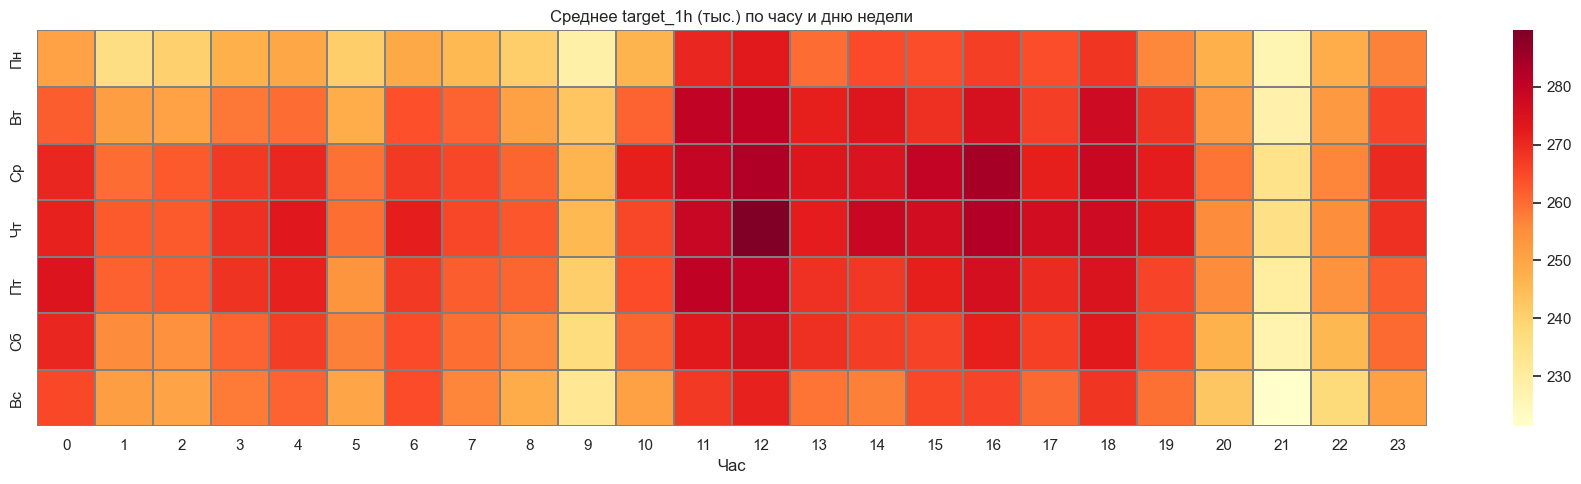

💡 Ночные часы немного слабее дневных; Понедельник — самый слабый день


In [9]:
pivot = train.groupby(['dow','hour'])[TARGET].mean().unstack()
pivot.index = ['Пн','Вт','Ср','Чт','Пт','Сб','Вс']

plt.figure(figsize=(18, 5))
sns.heatmap(pivot / 1e3, annot=False, fmt='.0f', cmap='YlOrRd',
            linewidths=0.3, linecolor='grey')
plt.title('Среднее target_1h (тыс.) по часу и дню недели')
plt.xlabel('Час')
plt.tight_layout()
plt.show()
print('💡 Ночные часы немного слабее дневных; Понедельник — самый слабый день')

## 8. Гетерогенность маршрутов

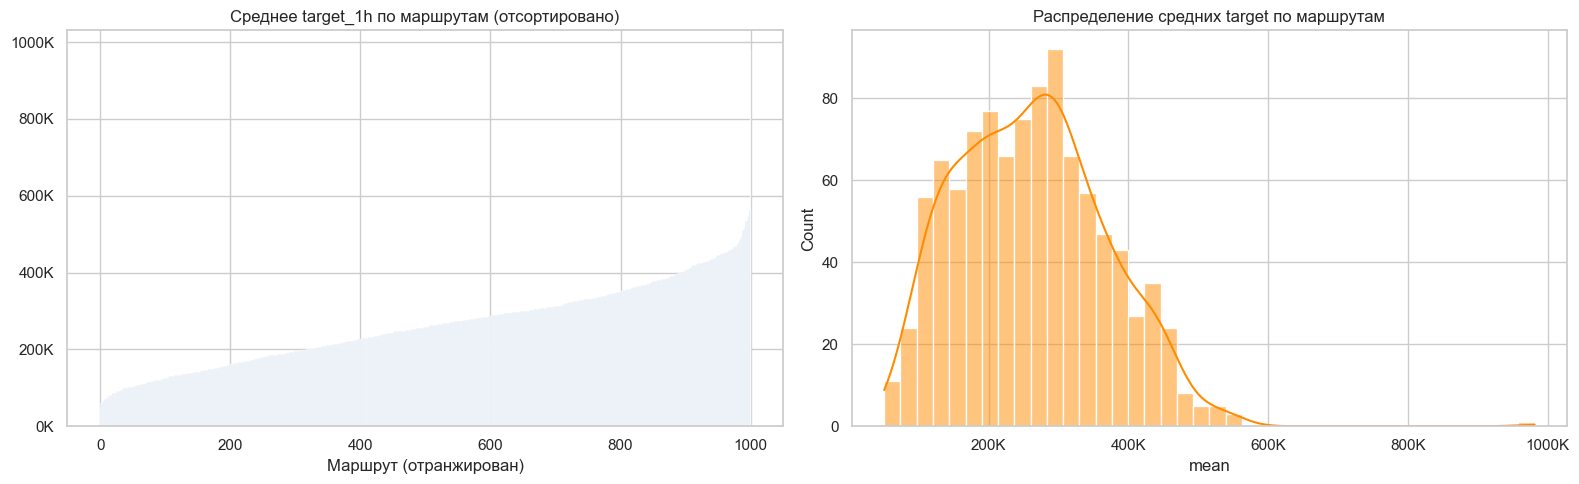

Маршруты: min_mean=50752, max_mean=981152
Разброс средних: в 19x раз
💡 Маршруты ОЧЕНЬ разные — модели с route_id как категорией важны!


In [10]:
route_stats = train.groupby('route_id')[TARGET].agg(['mean','median','std']).sort_values('mean')

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].bar(range(len(route_stats)), route_stats['mean'], width=1, color='steelblue', alpha=0.7)
axes[0].set_title('Среднее target_1h по маршрутам (отсортировано)')
axes[0].set_xlabel('Маршрут (отранжирован)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x/1e3:.0f}K'))

sns.histplot(route_stats['mean'], bins=40, ax=axes[1], color='darkorange', kde=True)
axes[1].set_title('Распределение средних target по маршрутам')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x/1e3:.0f}K'))

plt.tight_layout()
plt.show()

print(f'Маршруты: min_mean={route_stats["mean"].min():.0f}, max_mean={route_stats["mean"].max():.0f}')
print(f'Разброс средних: в {route_stats["mean"].max()/route_stats["mean"].min():.0f}x раз')
print('💡 Маршруты ОЧЕНЬ разные — модели с route_id как категорией важны!')

## 9. Анализ фичей status_*

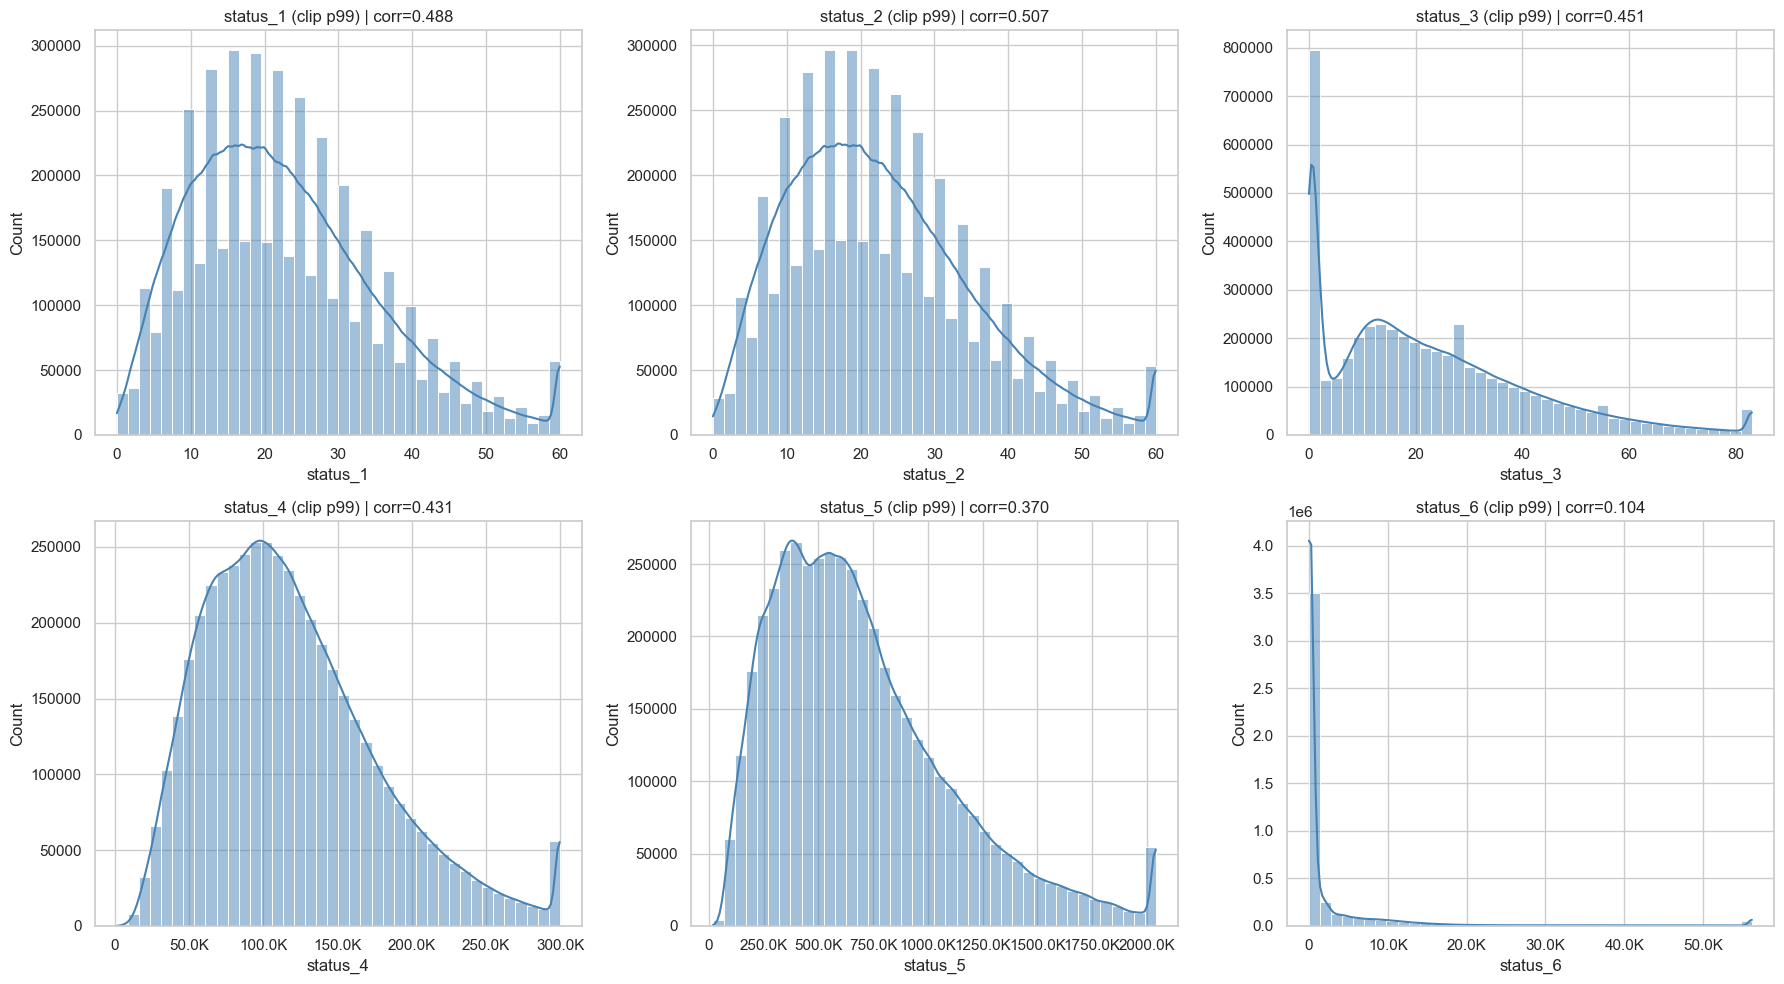

Средние значения фичей:
  status_1: mean=22.7, std=13.0, zeros=0.25%
  status_2: mean=22.9, std=12.9, zeros=0.21%
  status_3: mean=22.9, std=19.4, zeros=7.73%
  status_4: mean=119215.6, std=59825.7, zeros=0.00%
  status_5: mean=701978.9, std=421306.3, zeros=0.00%
  status_6: mean=3344.6, std=10048.2, zeros=0.10%


In [11]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(STATUS_COLS):
    p99 = train[col].quantile(0.99)
    sns.histplot(train[col].clip(upper=p99), bins=40, ax=axes[i], kde=True, color='steelblue')
    corr_val = train[[col, TARGET]].corr().iloc[0,1]
    axes[i].set_title(f'{col} (clip p99) | corr={corr_val:.3f}')
    axes[i].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x/1e3:.1f}K' if x > 1000 else f'{x:.0f}'))

plt.tight_layout()
plt.show()

# Масштабы
print('Средние значения фичей:')
for col in STATUS_COLS:
    print(f'  {col}: mean={train[col].mean():.1f}, std={train[col].std():.1f}, zeros={( train[col]==0).mean():.2%}')

## 10. Взаимосвязь status_* между собой

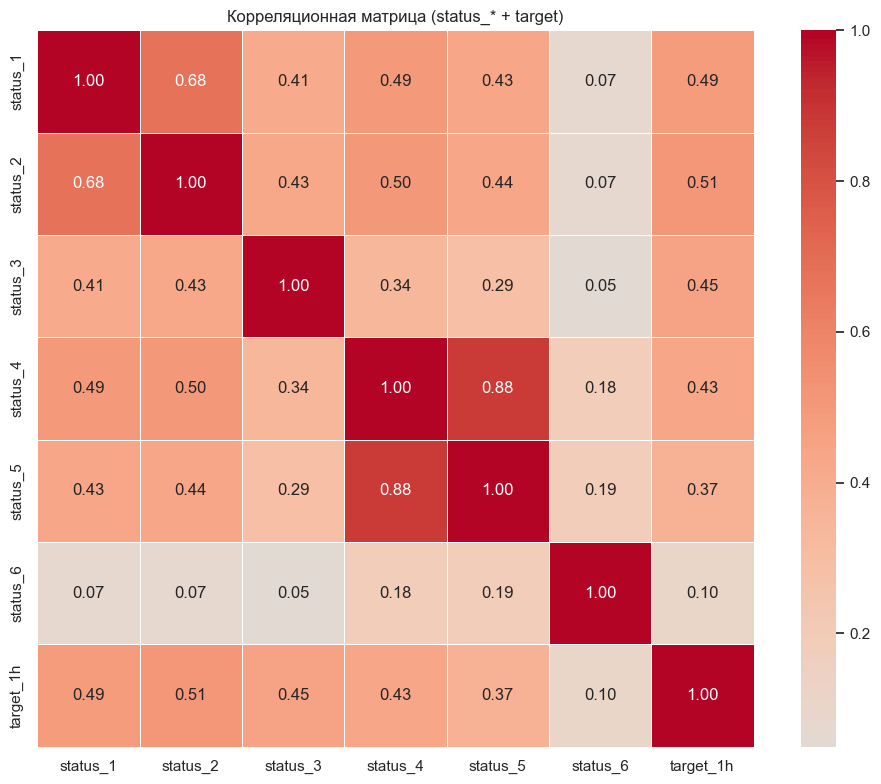

💡 status_1 и status_2 очень похожи (corr > 0.9?) — возможна мультиколлинеарность
💡 status_4 и status_5 — другой масштаб, но тоже коррелируют с target


In [12]:
corr_matrix = train[STATUS_COLS + [TARGET]].corr()

plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix), k=1)
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            mask=False, square=True, linewidths=0.5)
plt.title('Корреляционная матрица (status_* + target)')
plt.tight_layout()
plt.show()

print('💡 status_1 и status_2 очень похожи (corr > 0.9?) — возможна мультиколлинеарность')
print('💡 status_4 и status_5 — другой масштаб, но тоже коррелируют с target')

## 11. Динамика status_* по часам (тест — те же часы)

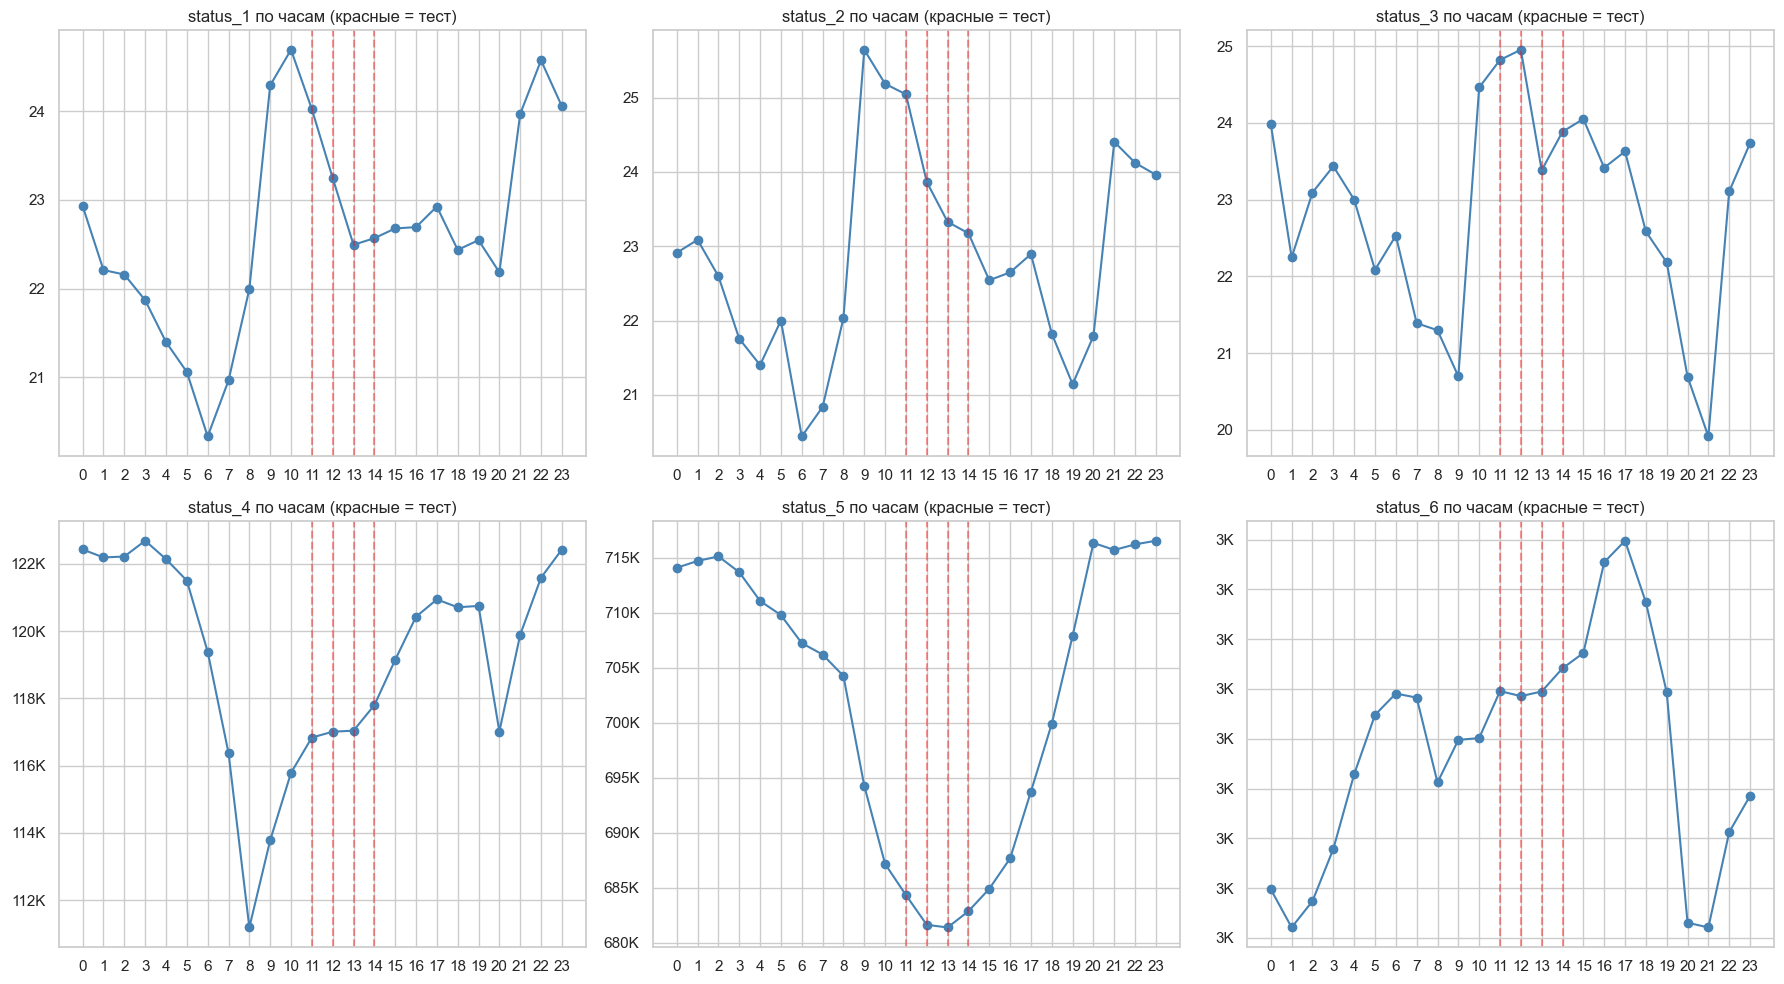

In [13]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(STATUS_COLS):
    hourly_s = train.groupby('hour')[col].mean()
    axes[i].plot(hourly_s.index, hourly_s.values, marker='o', color='steelblue')
    for h in [11, 12, 13, 14]:
        axes[i].axvline(h, color='red', linestyle='--', alpha=0.4)
    axes[i].set_title(f'{col} по часам (красные = тест)')
    axes[i].set_xticks(range(24))
    axes[i].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x/1e3:.0f}K' if x > 1000 else f'{x:.0f}'))

plt.tight_layout()
plt.show()

## 12. Инсайт: похожие субботы в train

In [14]:
# Найдем все субботы в train
train['date'] = train.timestamp.dt.date
saturdays = train[train.dow == 5]['date'].unique()
print(f'Субботы в train: {sorted(saturdays)}')
print(f'Тестовый день: 2025-11-01 (суббота)')
print()

# Среднее target_1h в тестовые часы по субботам
test_hours = [11, 12, 13, 14]
sat_data = train[(train.dow == 5) & (train.hour.isin(test_hours))]
sat_by_date = sat_data.groupby('date')[TARGET].mean()
print('Среднее target в часы 11-14 по субботам:')
for d, v in sat_by_date.items():
    print(f'  {d}: {v:.0f}')

print()
print('💡 Прошлая суббота (25 октября) — ближайший аналог тестового дня!')
print('💡 Lag 1 неделю назад — сильнейший признак для прогноза!')

Субботы в train: [datetime.date(2025, 8, 2), datetime.date(2025, 8, 9), datetime.date(2025, 8, 16), datetime.date(2025, 8, 23), datetime.date(2025, 8, 30), datetime.date(2025, 9, 6), datetime.date(2025, 9, 13), datetime.date(2025, 9, 20), datetime.date(2025, 9, 27), datetime.date(2025, 10, 4), datetime.date(2025, 10, 11), datetime.date(2025, 10, 18), datetime.date(2025, 10, 25), datetime.date(2025, 11, 1)]
Тестовый день: 2025-11-01 (суббота)

Среднее target в часы 11-14 по субботам:
  2025-08-02: 226056
  2025-08-09: 231101
  2025-08-16: 235335
  2025-08-23: 240140
  2025-08-30: 272670
  2025-09-06: 294214
  2025-09-13: 290011
  2025-09-20: 287554
  2025-09-27: 299736
  2025-10-04: 296932
  2025-10-11: 276121
  2025-10-18: 284517
  2025-10-25: 289587

💡 Прошлая суббота (25 октября) — ближайший аналог тестового дня!
💡 Lag 1 неделю назад — сильнейший признак для прогноза!


## 13. Автокорреляция target_1h (один маршрут)

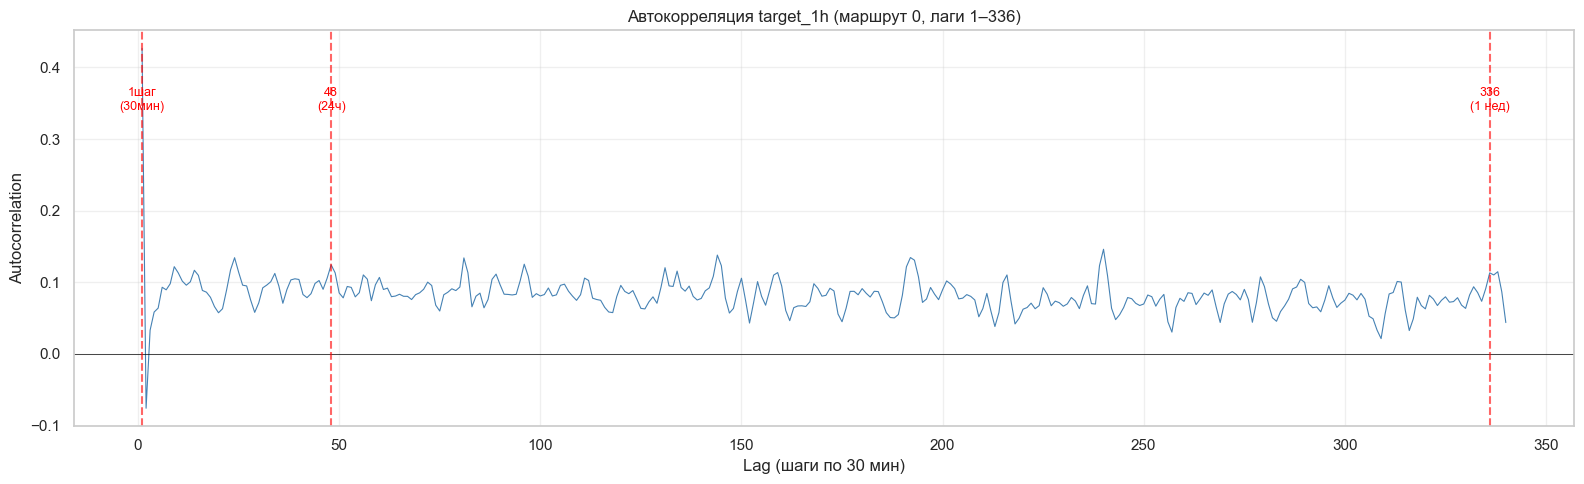

  lag_1 (30мин): autocorr = 0.427
  lag_2 (1ч): autocorr = -0.076
  lag_48 (24ч): autocorr = 0.124
  lag_336 (1 нед): autocorr = 0.113


In [15]:
from pandas.plotting import autocorrelation_plot

# Берём маршрут 0 для примера
route0 = train[train.route_id == 0].sort_values('timestamp')[TARGET]

# Ручная автокорреляция для нужных лагов
lags_of_interest = [1, 2, 3, 4, 6, 8,     # до 4 часов
                    24, 48,                  # 12ч, 24ч
                    48*7, 48*7+1, 48*7+2]   # неделя назад ±1 шаг

autocorrs = [(lag, route0.autocorr(lag=lag)) for lag in range(1, 48*7+5)]
lag_vals, corr_vals = zip(*autocorrs)

plt.figure(figsize=(16, 5))
plt.plot(lag_vals, corr_vals, linewidth=0.8, color='steelblue')
plt.axhline(0, color='black', linewidth=0.5)

# Отмечаем ключевые лаги
key_lags = {'1шаг\n(30мин)': 1, '48\n(24ч)': 48, '336\n(1 нед)': 336}
for label, lag in key_lags.items():
    if lag < len(corr_vals):
        plt.axvline(lag, color='red', linestyle='--', alpha=0.6)
        plt.annotate(label, xy=(lag, max(corr_vals)*0.8), fontsize=9, color='red', ha='center')

plt.title('Автокорреляция target_1h (маршрут 0, лаги 1–336)')
plt.xlabel('Lag (шаги по 30 мин)')
plt.ylabel('Autocorrelation')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Вывод ключевых значений
for lag, name in [(1,'lag_1 (30мин)'), (2,'lag_2 (1ч)'), (48,'lag_48 (24ч)'), (336,'lag_336 (1 нед)')]:
    ac = route0.autocorr(lag=lag)
    print(f'  {name}: autocorr = {ac:.3f}')

## 14. Тренд — есть ли рост/спад за период?

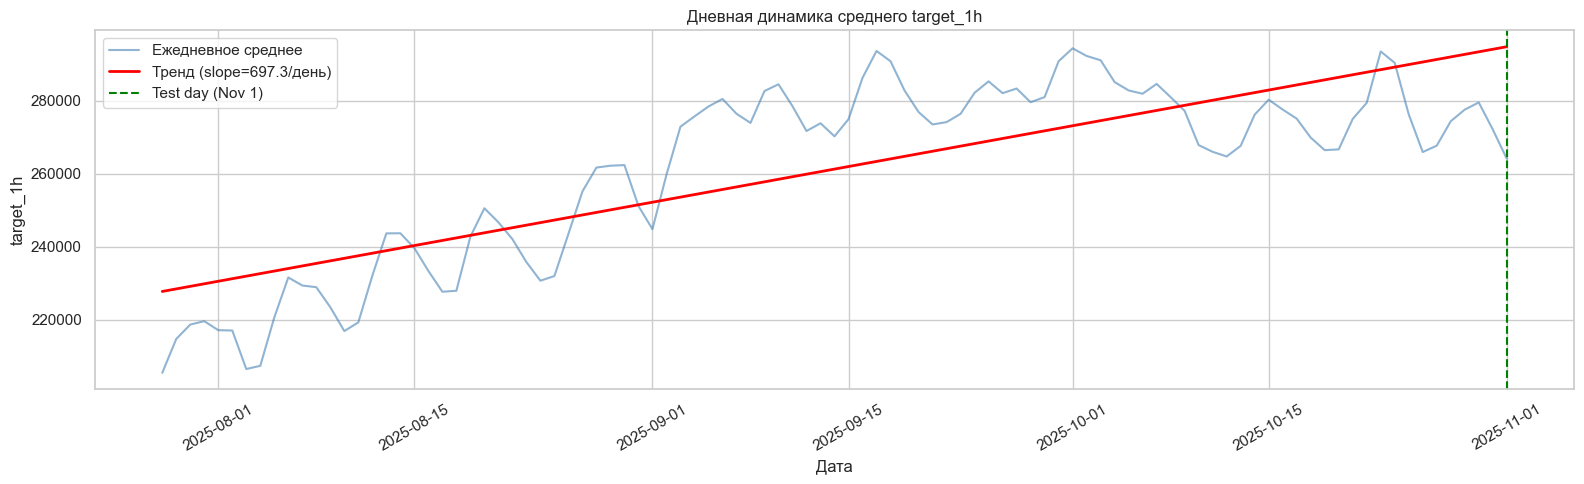

Линейный тренд: 697.3 ед/день, R²=0.633, p=0.0000
💡 Тренд статистически значим! Slope = 697 / день


In [17]:
daily_mean = train.groupby('date')[TARGET].mean().reset_index()
daily_mean['date_num'] = range(len(daily_mean))

slope, intercept, r, p, se = stats.linregress(daily_mean['date_num'], daily_mean[TARGET])

plt.figure(figsize=(16, 5))
plt.plot(daily_mean['date'], daily_mean[TARGET], alpha=0.6, color='steelblue', label='Ежедневное среднее')
trend_line = slope * daily_mean['date_num'] + intercept
plt.plot(daily_mean['date'], trend_line, color='red', linewidth=2, label=f'Тренд (slope={slope:.1f}/день)')
plt.axvline(pd.Timestamp('2025-11-01'), color='green', linestyle='--', label='Test day (Nov 1)')
plt.title('Дневная динамика среднего target_1h')
plt.xlabel('Дата')
plt.ylabel('target_1h')
plt.xticks(rotation=30)
plt.legend()
plt.tight_layout()
plt.show()

print(f'Линейный тренд: {slope:.1f} ед/день, R²={r**2:.3f}, p={p:.4f}')
if p < 0.05:
    print(f'💡 Тренд статистически значим! Slope = {slope:.0f} / день')
else:
    print('Тренд не значим (p >= 0.05)')

## 15. Инсайт: поведение 1 ноября утром vs прогноз

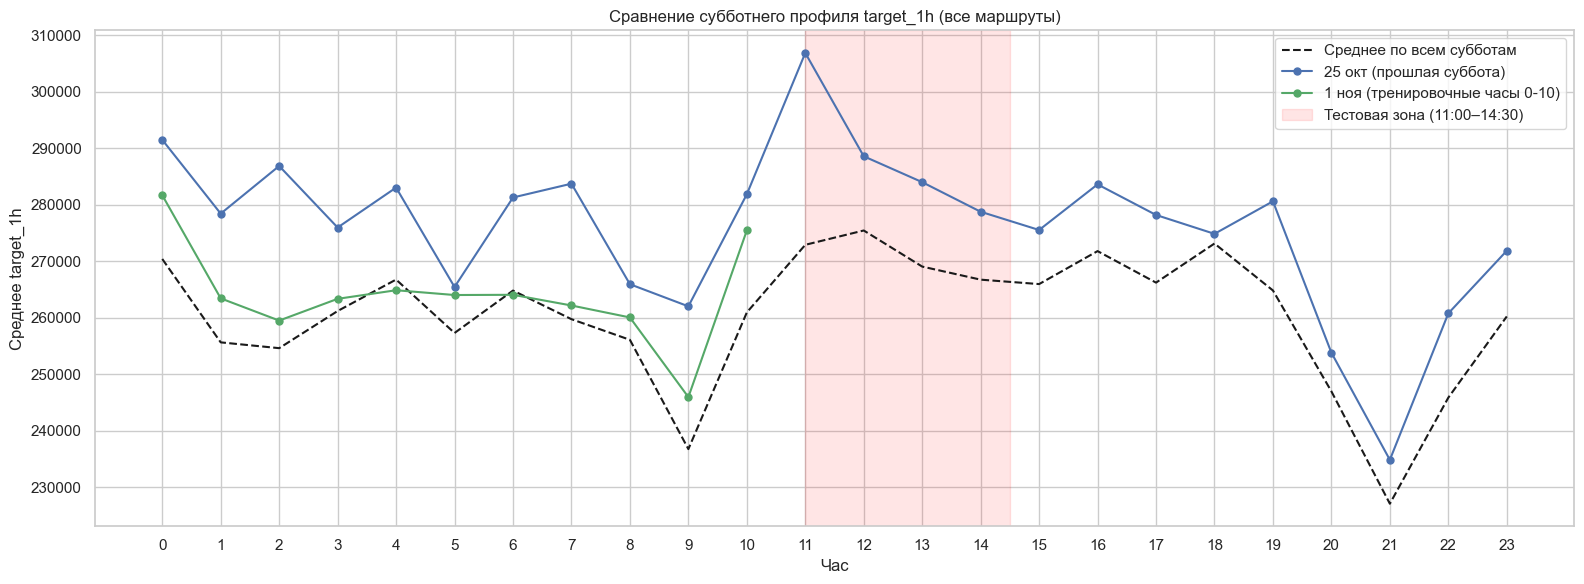

Соотношение nov1 / oct25 по часам (утро):
hour
0     0.966
1     0.946
2     0.905
3     0.954
4     0.936
5     0.995
6     0.939
7     0.924
8     0.978
9     0.939
10    0.977
11      NaN
12      NaN
13      NaN
14      NaN
15      NaN
16      NaN
17      NaN
18      NaN
19      NaN
20      NaN
21      NaN
22      NaN
23      NaN
Name: target_1h, dtype: float64

Среднее соотношение: 0.951
💡 Если соотношение ~1, то уровень 1 ноября ≈ уровень 25 октября!


In [19]:
# Сравниваем 1 ноября утром с прошлой субботой 25 октября и средней субботой
oct25 = train[train.timestamp.dt.date == pd.Timestamp('2025-10-25').date()]
nov01 = train[train.timestamp.dt.date == pd.Timestamp('2025-11-01').date()]

# Среднее по всем субботам
all_sats = train[train.dow == 5]
sat_avg_by_hour = all_sats.groupby('hour')[TARGET].mean()

oct25_hour = oct25.groupby('hour')[TARGET].mean()
nov01_hour = nov01.groupby('hour')[TARGET].mean()

plt.figure(figsize=(16, 6))
plt.plot(sat_avg_by_hour.index, sat_avg_by_hour.values, 'k--', linewidth=1.5, label='Среднее по всем субботам')
plt.plot(oct25_hour.index, oct25_hour.values, 'b-o', markersize=5, label='25 окт (прошлая суббота)')
plt.plot(nov01_hour.index, nov01_hour.values, 'g-o', markersize=5, label='1 ноя (тренировочные часы 0-10)')

# Отмечаем тестовую зону
plt.axvspan(11, 14.5, alpha=0.1, color='red', label='Тестовая зона (11:00–14:30)')

plt.title('Сравнение субботнего профиля target_1h (все маршруты)')
plt.xlabel('Час')
plt.ylabel('Среднее target_1h')
plt.xticks(range(24))
plt.legend()
plt.tight_layout()
plt.show()

# Соотношение 1 ноября к 25 октября утром
ratio = nov01_hour / oct25_hour
print('Соотношение nov1 / oct25 по часам (утро):')
print(ratio.round(3))
print(f'\nСреднее соотношение: {ratio.mean():.3f}')
print('💡 Если соотношение ~1, то уровень 1 ноября ≈ уровень 25 октября!')

## 16. Scatter: status vs target

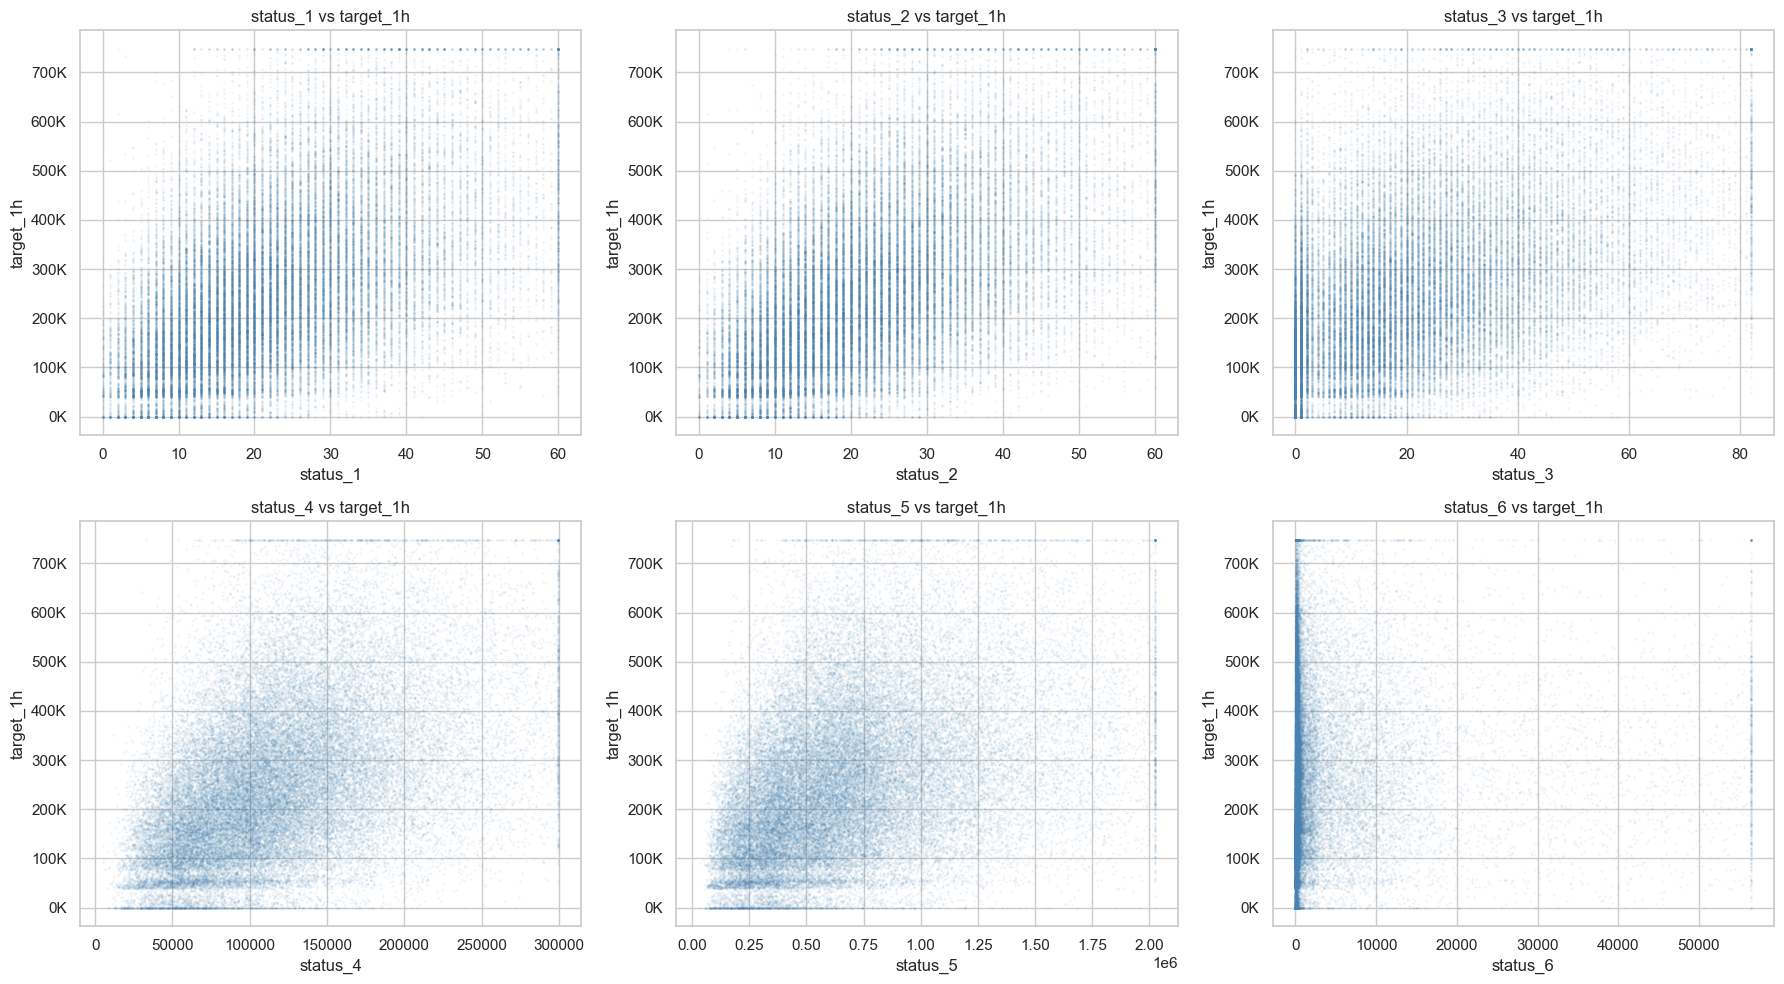

In [20]:
# Сэмплируем для скорости
sample = train.sample(50_000, random_state=42)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(STATUS_COLS):
    axes[i].scatter(sample[col].clip(upper=sample[col].quantile(0.99)),
                   sample[TARGET].clip(upper=sample[TARGET].quantile(0.99)),
                   alpha=0.05, s=1, color='steelblue')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel(TARGET)
    axes[i].set_title(f'{col} vs {TARGET}')
    axes[i].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x/1e3:.0f}K'))

plt.tight_layout()
plt.show()

## 17. Итоговые инсайты и рекомендации для моделирования

In [21]:
print('=' * 70)
print('КЛЮЧЕВЫЕ ИНСАЙТЫ')
print('=' * 70)
print()
print('📊 ДАННЫЕ:')
print('  • 1000 маршрутов, 4630 точек каждый (30-мин шаг)')
print('  • Train: 28 июл – 1 ноя 2025 | Test: 1 ноя 11:00–14:30')
print('  • Нет пропусков, нет NaN, ~1.5% нулей в target')
print()
print('🔑 ГЛАВНЫЙ ИНСАЙТ — same-day context:')
print('  • Данные 1 ноября с 00:00 по 10:30 есть в train!')
print('  • Предсказываем 11:00–14:30 того же дня')
print('  => Утренние status-значения 1 ноября — мощный сигнал')
print()
print('📈 ЛУЧШИЕ ПРИЗНАКИ ДЛЯ МОДЕЛИ:')
print('  1. Lag 336 (1 неделя назад = та же суббота 25 окт)')
print('  2. Lag 48 (24 часа назад = в норме не суббота, но близко)')
print('  3. status_1, status_2 текущего момента (corr ~0.5)')
print('  4. Среднее/медиана маршрута за последние N дней')
print('  5. Утреннее значение того же дня (same-day mean/last)')
print('  6. hour, dow (тестовые часы выше среднего!)')
print()
print('⚠️  ОСТОРОЖНО:')
print('  • status_6 — слабая корреляция, много выбросов')
print('  • target имеет тяжёлый хвост (max = 10.8M vs median = 235K)')
print('  • Маршруты ОЧЕНЬ разные — без route_id модель будет плохой')
print('  • Метрика WAPE + RBias — чувствительна к системному смещению!')
print()
print('🎯 СТРАТЕГИЯ:')
print('  • Базовый прогноз: lag_336 (то же время прошлой субботы)')
print('  • Коррекция на дневной уровень: ratio = nov1_morning / oct25_morning')
print('  • LightGBM с фичами лагов + hour + dow + route_id')
print('  • Потенциал улучшения: учесть тренд + same-day scaling')

КЛЮЧЕВЫЕ ИНСАЙТЫ

📊 ДАННЫЕ:
  • 1000 маршрутов, 4630 точек каждый (30-мин шаг)
  • Train: 28 июл – 1 ноя 2025 | Test: 1 ноя 11:00–14:30
  • Нет пропусков, нет NaN, ~1.5% нулей в target

🔑 ГЛАВНЫЙ ИНСАЙТ — same-day context:
  • Данные 1 ноября с 00:00 по 10:30 есть в train!
  • Предсказываем 11:00–14:30 того же дня
  => Утренние status-значения 1 ноября — мощный сигнал

📈 ЛУЧШИЕ ПРИЗНАКИ ДЛЯ МОДЕЛИ:
  1. Lag 336 (1 неделя назад = та же суббота 25 окт)
  2. Lag 48 (24 часа назад = в норме не суббота, но близко)
  3. status_1, status_2 текущего момента (corr ~0.5)
  4. Среднее/медиана маршрута за последние N дней
  5. Утреннее значение того же дня (same-day mean/last)
  6. hour, dow (тестовые часы выше среднего!)

⚠️  ОСТОРОЖНО:
  • status_6 — слабая корреляция, много выбросов
  • target имеет тяжёлый хвост (max = 10.8M vs median = 235K)
  • Маршруты ОЧЕНЬ разные — без route_id модель будет плохой
  • Метрика WAPE + RBias — чувствительна к системному смещению!

🎯 СТРАТЕГИЯ:
  • Базовый пр